In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

In [2]:
!pip install -q kagglehub

In [3]:
import kagglehub
path = kagglehub.dataset_download("abdallahalidev/plantvillage-dataset")

Using Colab cache for faster access to the 'plantvillage-dataset' dataset.


In [6]:
from pathlib import Path
dataset = Path(path)

In [5]:
root = dataset / "plantvillage dataset"

In [7]:
color_path = root / "color"

In [8]:
IMG_SIZE = (256, 256)
BATCH_SIZE = 8
SEED = 42

In [9]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    color_path,
    validation_split=0.3,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

temp_ds = tf.keras.utils.image_dataset_from_directory(
    color_path,
    validation_split=0.3,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 54305 files belonging to 38 classes.
Using 38014 files for training.
Found 54305 files belonging to 38 classes.
Using 16291 files for validation.


In [10]:
class_names = temp_ds.class_names

In [11]:
val_batches = int(0.5 * tf.data.experimental.cardinality(temp_ds).numpy())

val_ds = temp_ds.take(val_batches)
test_ds = temp_ds.skip(val_batches)

In [12]:
print(tf.data.experimental.cardinality(train_ds))
print(tf.data.experimental.cardinality(val_ds))
print(tf.data.experimental.cardinality(test_ds))

tf.Tensor(4752, shape=(), dtype=int64)
tf.Tensor(1018, shape=(), dtype=int64)
tf.Tensor(1019, shape=(), dtype=int64)


In [13]:
print(train_ds.class_names)
print(len(train_ds.class_names))

['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Sp

In [16]:
for images, labels in train_ds.take(1):
    print(images.shape)
    print(labels.shape)

(8, 256, 256, 3)
(8,)


In [17]:
num_classes = len(train_ds.class_names)
print(num_classes)


38


In [18]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

In [19]:
from tensorflow.keras.applications import EfficientNetB0


In [20]:
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(256, 256, 3)
)

base_model.trainable = False

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [21]:
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation="softmax")
])

In [22]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [23]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 8, 8, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 38)             │        48,678 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,098,249 (15.63 MB)

 Trainable params: 48,678 (190.15 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [24]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint
)

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),

    ModelCheckpoint(
        "best_model.keras",
        monitor="val_accuracy",
        save_best_only=True
    ),
]

In [25]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks
)

Epoch 1/20
4752/4752 ━━━━━━━━━━━━━━━━━━━━ 213s 33ms/step - accuracy: 0.9013 - loss: 0.3844 - val_accuracy: 0.9638 - val_loss: 0.1292
Epoch 2/20
4752/4752 ━━━━━━━━━━━━━━━━━━━━ 126s 23ms/step - accuracy: 0.9558 - loss: 0.1452 - val_accuracy: 0.9705 - val_loss: 0.0925
Epoch 3/20
4752/4752 ━━━━━━━━━━━━━━━━━━━━ 101s 18ms/step - accuracy: 0.9615 - loss: 0.1180 - val_accuracy: 0.9759 - val_loss: 0.0793
Epoch 4/20
4752/4752 ━━━━━━━━━━━━━━━━━━━━ 90s 18ms/step - accuracy: 0.9667 - loss: 0.1025 - val_accuracy: 0.9754 - val_loss: 0.0726
Epoch 5/20
4752/4752 ━━━━━━━━━━━━━━━━━━━━ 91s 18ms/step - accuracy: 0.9683 - loss: 0.0935 - val_accuracy: 0.9780 - val_loss: 0.0704
Epoch 6/20
4752/4752 ━━━━━━━━━━━━━━━━━━━━ 90s 18ms/step - accuracy: 0.9706 - loss: 0.0871 - val_accuracy: 0.9757 - val_loss: 0.0754
Epoch 7/20
4752/4752 ━━━━━━━━━━━━━━━━━━━━ 142s 18ms/step - accuracy: 0.9716 - loss: 0.0864 - val_accuracy: 0.9769 - val_loss: 0.0742
Epoch 8/20
4752/4752 ━━━━━━━━━━━━━━━━━━━━ 91s 18ms/step - accuracy: 0.97

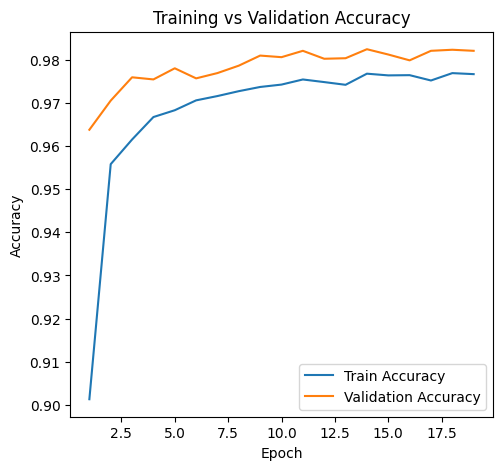

In [26]:
accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

epochs = range(1, len(accuracy) + 1)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(epochs, accuracy, label='Train Accuracy')
plt.plot(epochs, val_accuracy, label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.show()

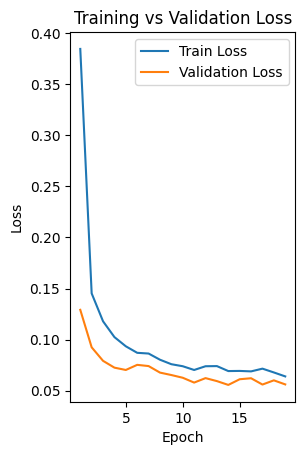

In [27]:
loss = history.history['loss']
val_loss = history.history['val_loss']
plt.subplot(1,2,2)
plt.plot(epochs, loss, label='Train Loss')
plt.plot(epochs, val_loss, label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

In [28]:
loss, accuracy = model.evaluate(val_ds)

print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

1018/1018 ━━━━━━━━━━━━━━━━━━━━ 16s 16ms/step - accuracy: 0.9826 - loss: 0.0556
Validation Loss: 0.0556
Validation Accuracy: 0.9826


In [37]:
loss, accuracy = model.evaluate(test_ds)

print(f"Testing Loss: {loss:.4f}")
print(f"Testing Accuracy: {accuracy:.4f}")

1019/1019 ━━━━━━━━━━━━━━━━━━━━ 51s 27ms/step - accuracy: 0.9822 - loss: 0.0548
Testing Loss: 0.0548
Testing Accuracy: 0.9822


In [29]:
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

In [30]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

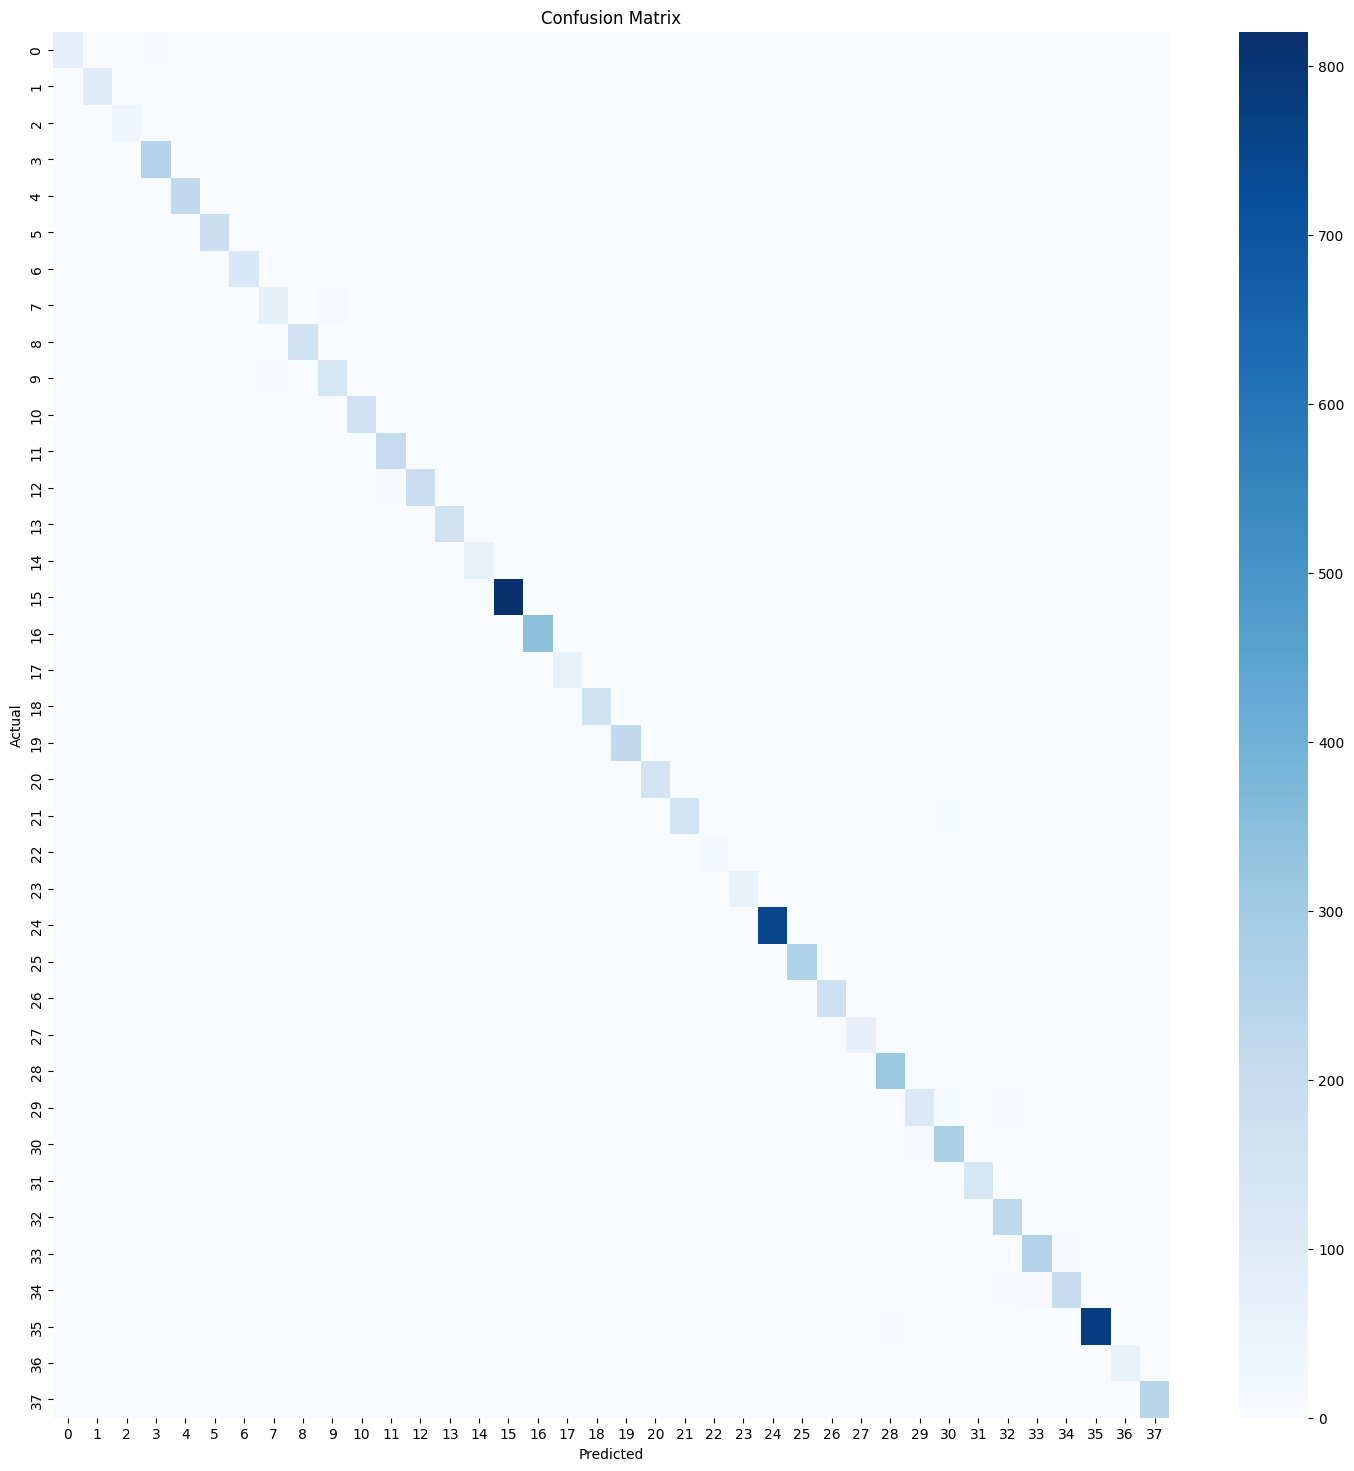

In [31]:
plt.figure(figsize=(18,18))
sns.heatmap(confusion_matrix(y_true,y_pred), cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

A strong diagonal means:

Most images are classified correctly.
The model is not confusing many diseases.
The high validation accuracy (~97.8%) is reflected visually.

In [32]:
from sklearn.metrics import classification_report

In [33]:
print(classification_report(
    y_true,
    y_pred,
    target_names= class_names
))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.99      0.90      0.94        92
                                 Apple___Black_rot       0.98      1.00      0.99        97
                          Apple___Cedar_apple_rust       1.00      1.00      1.00        40
                                   Apple___healthy       0.97      1.00      0.99       249
                               Blueberry___healthy       1.00      1.00      1.00       218
          Cherry_(including_sour)___Powdery_mildew       1.00      0.99      0.99       184
                 Cherry_(including_sour)___healthy       1.00      1.00      1.00       131
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.94      0.85      0.89        85
                       Corn_(maize)___Common_rust_       1.00      1.00      1.00       162
               Corn_(maize)___Northern_Leaf_Blight       0.91      0.96      0.

In [34]:
import os
print(os.listdir())

['.config', 'best_model.keras', 'sample_data']


best model saved

nothing much for hyperparam tuning needed as already the results were good

In [35]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [36]:
import shutil

shutil.copy(
    "best_model.keras",
    "/content/drive/MyDrive/best_model.keras"
)

'/content/drive/MyDrive/best_model.keras'